In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
performance = pd.read_csv(
    "../data/raw/07_scheme_performance.csv"
)

holdings = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

benchmark = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv"
)

In [6]:
top_sharpe = (
    performance
    .sort_values(
        "sharpe_ratio",
        ascending=False
    )
    .head(10)
)

top_sharpe

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,Regular,8.89,7.68,7.94,5.83,1.85,0.26,7.68,10.37,0.5,-2.62,39116,0.74,5,Low
23,120844,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Liquid,Regular,4.26,6.18,8.26,4.66,1.52,0.47,6.18,9.70,0.5,-3.81,27623,0.60,3,Low
30,101208,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Liquid,Regular,6.18,5.14,7.95,3.96,1.18,0.43,5.14,8.76,0.5,-3.66,38995,0.79,5,Low
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,Regular,6.83,7.37,6.41,5.39,1.98,0.44,1.84,2.79,4.0,-6.01,27953,0.56,3,Low
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low
19,118636,Nippon India Gilt Securities Fund - Regular - ...,Nippon India MF,Gilt,Regular,6.19,5.31,8.71,4.42,0.89,0.37,1.33,2.38,4.0,-2.23,30030,0.55,4,Low
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,0.96,1.06,1.66,14.0,-17.07,11361,1.46,5,Moderate
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,14.06,0.78,0.97,1.06,1.70,14.0,-17.41,6434,1.55,5,Moderate
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,Direct,14.12,14.41,13.02,13.53,0.88,1.03,1.03,1.27,14.0,-26.59,41553,0.80,3,Moderate
15,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,Large Cap,Regular,15.84,14.00,14.70,13.14,0.86,0.88,1.00,1.68,14.0,-16.07,20909,1.51,4,Moderate


In [7]:
top_alpha = (
    performance
    .sort_values(
        "alpha",
        ascending=False
    )
    .head(10)
)

top_alpha

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,Regular,6.83,7.37,6.41,5.39,1.98,0.44,1.84,2.79,4.0,-6.01,27953,0.56,3,Low
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,Regular,17.12,18.23,17.75,16.32,1.91,1.00,0.96,1.27,19.0,-21.92,47469,1.56,4,High
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,Regular,8.89,7.68,7.94,5.83,1.85,0.26,7.68,10.37,0.5,-2.62,39116,0.74,5,Low
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,15.74,15.65,13.50,13.80,1.85,0.95,0.98,1.57,16.0,-19.50,35012,1.45,5,Moderately High
29,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,Regular,24.93,22.38,23.80,20.54,1.84,0.97,0.90,1.47,25.0,-23.61,41613,1.53,5,Very High
37,149322,DSP Top 100 Equity Fund - Regular - Growth,DSP Mutual Fund,Large Cap,Regular,11.96,12.82,12.35,11.00,1.82,0.91,0.92,1.63,14.0,-21.70,41828,1.54,5,Moderate
18,118635,Nippon India ETF Nifty 50 BeES,Nippon India MF,Index/ETF,Direct,10.14,11.77,12.31,9.97,1.80,1.04,0.91,1.24,13.0,-26.75,20284,0.89,5,Moderate
33,102887,UTI Flexi Cap Fund - Regular - Growth,UTI Mutual Fund,Flexi Cap,Regular,17.43,15.34,15.78,13.55,1.79,1.00,0.96,1.37,16.0,-12.14,17912,1.64,5,Moderately High
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
35,148568,Mirae Asset Emerging Bluechip Fund - Regular -...,Mirae Asset MF,Large & Mid Cap,Regular,14.91,14.56,15.68,12.86,1.70,0.99,0.91,1.55,16.0,-33.15,49046,1.52,5,Moderately High


<Axes: xlabel='std_dev_ann_pct', ylabel='return_3yr_pct'>

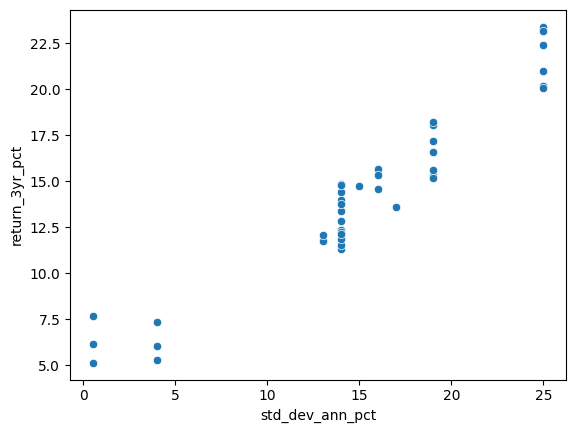

In [8]:
sns.scatterplot(
    data=performance,
    x="std_dev_ann_pct",
    y="return_3yr_pct"
)

In [9]:
[
"return_1yr_pct",
"return_3yr_pct",
"return_5yr_pct",
"alpha",
"beta",
"sharpe_ratio",
"std_dev_ann_pct",
"max_drawdown_pct"
]

['return_1yr_pct',
 'return_3yr_pct',
 'return_5yr_pct',
 'alpha',
 'beta',
 'sharpe_ratio',
 'std_dev_ann_pct',
 'max_drawdown_pct']

In [10]:
performance["score"] = (
    0.4 * performance["return_3yr_pct"]
    + 0.3 * performance["sharpe_ratio"] * 10
    + 0.2 * performance["alpha"]
    - 0.1 * abs(
        performance["max_drawdown_pct"]
    )
)

In [11]:
performance.sort_values(
    "score",
    ascending=False
).head(10)

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,score
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,Regular,8.89,7.68,7.94,5.83,1.85,0.26,7.68,10.37,0.5,-2.62,39116,0.74,5,Low,26.220
23,120844,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Liquid,Regular,4.26,6.18,8.26,4.66,1.52,0.47,6.18,9.70,0.5,-3.81,27623,0.60,3,Low,20.935
30,101208,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Liquid,Regular,6.18,5.14,7.95,3.96,1.18,0.43,5.14,8.76,0.5,-3.66,38995,0.79,5,Low,17.346
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,11.087
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,9.794
29,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,Regular,24.93,22.38,23.80,20.54,1.84,0.97,0.90,1.47,25.0,-23.61,41613,1.53,5,Very High,9.659
27,119095,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,Small Cap,Regular,21.97,20.98,22.62,20.47,0.51,1.00,0.84,1.40,25.0,-14.45,21545,1.38,4,Very High,9.569
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Small Cap,Regular,20.20,20.08,20.61,19.39,0.69,0.98,0.80,1.23,25.0,-17.01,35124,1.52,4,Very High,8.869
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,Regular,17.12,18.23,17.75,16.32,1.91,1.00,0.96,1.27,19.0,-21.92,47469,1.56,4,High,8.362
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,Regular,6.83,7.37,6.41,5.39,1.98,0.44,1.84,2.79,4.0,-6.01,27953,0.56,3,Low,8.263
